# 01. Data exploration: storm 33 at Upper Hafren

This notebook visualises the 26 June 2008 storm at the Upper Hafren
catchment, which is used as the calibration event in the manuscript.

The storm has the longest continuous chloride coverage in the 68-event
catalogue (12 grab samples over 84 hours) and a typical magnitude
(peak rainfall 12.5 mm/h, peak streamflow 3.75 m^3/s).

In [1]:
import sys; sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from uhf_sir import visualization as viz

## Load storm 33 hourly time series and 7-h chloride samples

In [2]:
WARMUP_HR = 168
STORM_ID  = 33

ts = pd.read_csv("../data/storm_timeseries_all.csv")
cl = pd.read_csv("../data/storm_chloride_all.csv")

ts33 = ts[ts["storm_id"] == STORM_ID].reset_index(drop=True)
cl33 = cl[cl["storm_id"] == STORM_ID].reset_index(drop=True)

# Time origin: t = 0 at rain onset (= warmup_start + 168 h)
ts33["t_h"] = (ts33["t_sec"] - WARMUP_HR * 3600) / 3600
cl33["t_h"] = (cl33["t_sec"] - WARMUP_HR * 3600) / 3600

print(f"Storm 33 hourly rows: {len(ts33)}")
print(f"Chloride samples:     {len(cl33)}")

Storm 33 hourly rows: 253
Chloride samples:     53


## Storm 33 summary statistics

In [3]:
cal = ts33[(ts33["t_h"] >= 0) & (ts33["t_h"] <= 84)]

print(f"Total rainfall (0-84 h):  {cal['rain_mmhr'].sum():.1f} mm")
print(f"Peak rainfall:            {cal['rain_mmhr'].max():.2f} mm/h")
print(f"Peak streamflow:          {cal['Q_obs_m3s'].max():.3f} m^3/s")

cl_stream = cl33[(cl33["kind"] == "stream") & (cl33["t_h"] >= 0) & (cl33["t_h"] <= 84)]
cl_rain   = cl33[(cl33["kind"] == "rain")   & (cl33["t_h"] >= 0) & (cl33["t_h"] <= 84)]

print(f"\nStream Cl trough:         {cl_stream['Cl_mgL'].min():.2f} mg/L")
print(f"Rain Cl range:            [{cl_rain['Cl_mgL'].min():.1f}, {cl_rain['Cl_mgL'].max():.1f}] mg/L")

Total rainfall (0-84 h):  85.0 mm
Peak rainfall:            12.50 mm/h
Peak streamflow:          3.749 m^3/s

Stream Cl trough:         3.86 mg/L
Rain Cl range:            [2.0, 14.3] mg/L


## Figure 1: empirical unit hydrograph

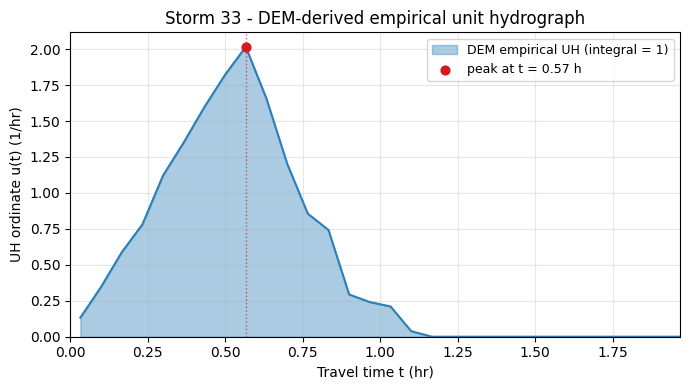

In [4]:
uh = np.load("../data/uhf_empirical_uh.npz")

fig, ax = plt.subplots(figsize=(7, 4))
viz.plot_catchment_and_uh(uh["t_hr"], uh["uh_hr_inv"], ax=ax)
ax.set_title("Storm 33 - DEM-derived empirical unit hydrograph")
plt.tight_layout()

## Figure E1: rainfall and stream chloride mass balance

The rainfall during this storm carries a higher chloride concentration
than the stream baseline (rainfall-weighted mean 9.7 mg/L versus
pre-storm baseline 5.5 mg/L). The observed dilution from 5.5 to
3.86 mg/L is therefore not classical event-water displacement.

e:\PythonProject\FinalProjectTest\UHF_SIR\notebooks\..\uhf_sir\visualization.py:544: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


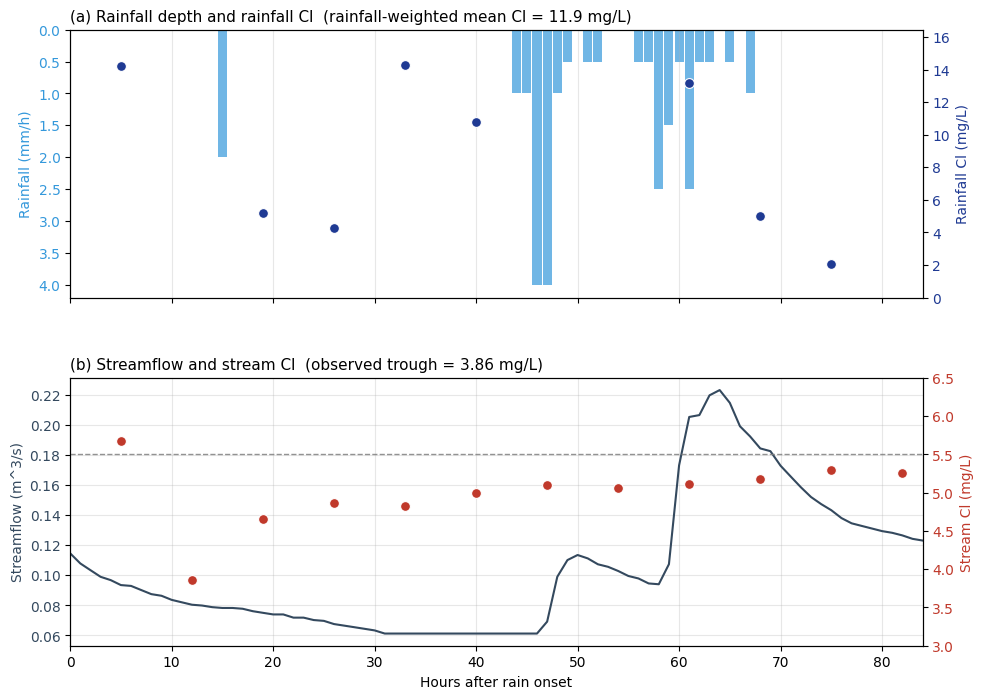

In [5]:
# Build storm_data dict for the visualisation helper
storm_data = {
    "rain_t":     ts33["t_sec"].values,
    "rain_flux":  ts33["rain_mmhr"].values,
    "rain_C":     np.zeros(len(ts33)),
    "t_Q_hourly": ts33["t_sec"].values - WARMUP_HR * 3600,
    "pre_Cl":     5.5,
    "Q_obs":      ts33["Q_obs_m3s"].values,
}

fig = viz.plot_mass_balance(
    storm_data,
    cl_rain["t_h"].values,   cl_rain["Cl_mgL"].values,
    cl_stream["t_h"].values, cl_stream["Cl_mgL"].values,
    pre_Cl=5.5,
)